# Pan-Cancer Meta-Analysis of Metastatic Metabolism
This notebook synthesizes the findings across all 5 analyzed cancer types (Breast, Colorectal, Lung, Melanoma, and Ovarian) to define a conserved pan-cancer metastatic metabolic signature, visualize its network context, and evaluate its predictive biomarker potential in primary tumors.


In [1]:
import pandas as pd
import os
from IPython.display import Image, display

BASE_DIR = os.path.dirname(os.path.abspath('.'))
OUTPUT_DIR = os.path.join(BASE_DIR, 'output')
META_RESULTS_DIR = os.path.join(OUTPUT_DIR, 'pan_cancer_meta_results')


### 1. Pan-Cancer Overlap of Metastatic Metabolic Reprogramming

**Goal:** Visually map the intersection of up-regulated metabolic genes across 5 distinct cancer types (Breast, Colorectal, Lung, Melanoma, and Ovarian).

**Purpose:** To identify strictly conserved genes that form a core "pan-cancer metastatic metabolic signature," independent of the primary tumor's tissue of origin.

**Inputs / Parameters:**
- **Breast:** `output/breast_results/primary_vs_metastasis_breast_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Colorectal:** `output/colorectal_results/primary_vs_metastasis_colorectal_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Lung:** `output/lung_results/primary_vs_metastasis_lung_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Melanoma:** `output/melanoma_results/primary_vs_metastasis_melanoma_results_DE_metabolic_targets_{cancer_suffix}.csv`
- **Ovarian:** `output/ovarian_results/primary_vs_metastasis_ovarian_results_DE_metabolic_targets_{cancer_suffix}.csv`

**Analysis:** We take the intersection of all target genes marked as `Up in Metastasis` across the 5 input files. This yields **strictly conserved pan-cancer metabolic targets**.

**Underlying Data (CSVs):**
- **UpSet Plot Data:** `output/pan_cancer_meta_results/upset_plot_data{ANALYSIS_SUFFIX}.csv` (contains the raw mapping of which gene belongs to which cancer's Up-Regulated set).
- **The Conserved Pan-Cancer Genes:** `output/pan_cancer_meta_results/pan_cancer_conserved_genes{ANALYSIS_SUFFIX}.csv` (contains the final intersected list).

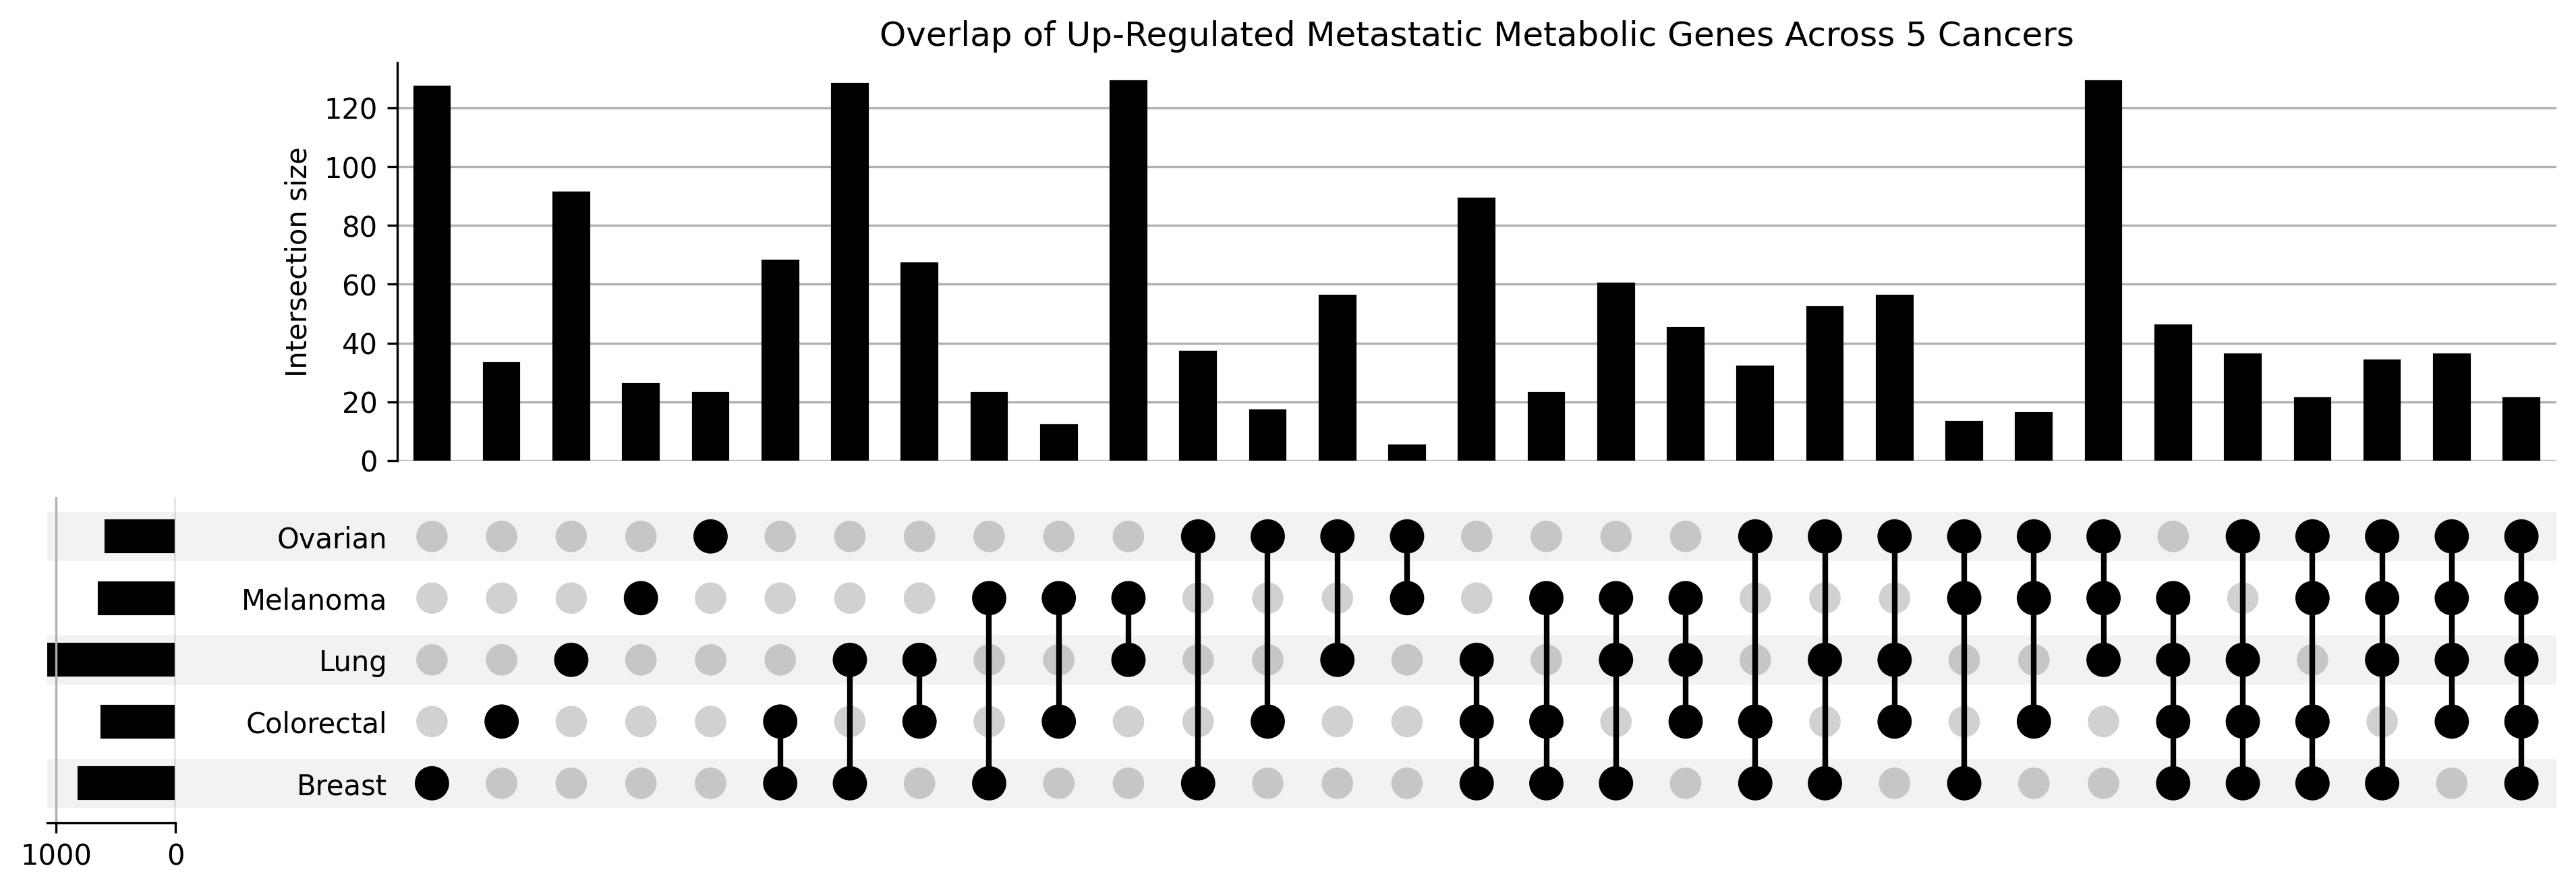

In [2]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

from IPython.display import Image, display
import os
base_dir = '..' if os.path.basename(os.getcwd()) == 'scripts' else '.'
image_path = os.path.join(base_dir, f'output/pan_cancer_meta_results/upset_plot{ANALYSIS_SUFFIX}.png')
display(Image(filename=image_path))

### 2. Conserved Metabolite-Target Network

**Goal:** Map the pan-cancer conserved genes against their interacting metabolites.

**Purpose:** To contextualize these strictly conserved genes into actionable biological pathways and identify highly connected metabolic hubs.

**Inputs / Parameters:**
- **Gene List:** The strictly conserved genes identified in Section 1 (`output/pan_cancer_meta_results/pan_cancer_conserved_genes{ANALYSIS_SUFFIX}.csv`).
- **Database:** `output/human_metab_target_pairs_cancer_annotated.csv` (our merged metabConnectomeDB pairs).

**Underlying Data (CSV):**
- **Network Edges:** `output/pan_cancer_meta_results/metabolite_target_network_edges{ANALYSIS_SUFFIX}.csv` (contains the raw Source-Target edges used to build this visualization).

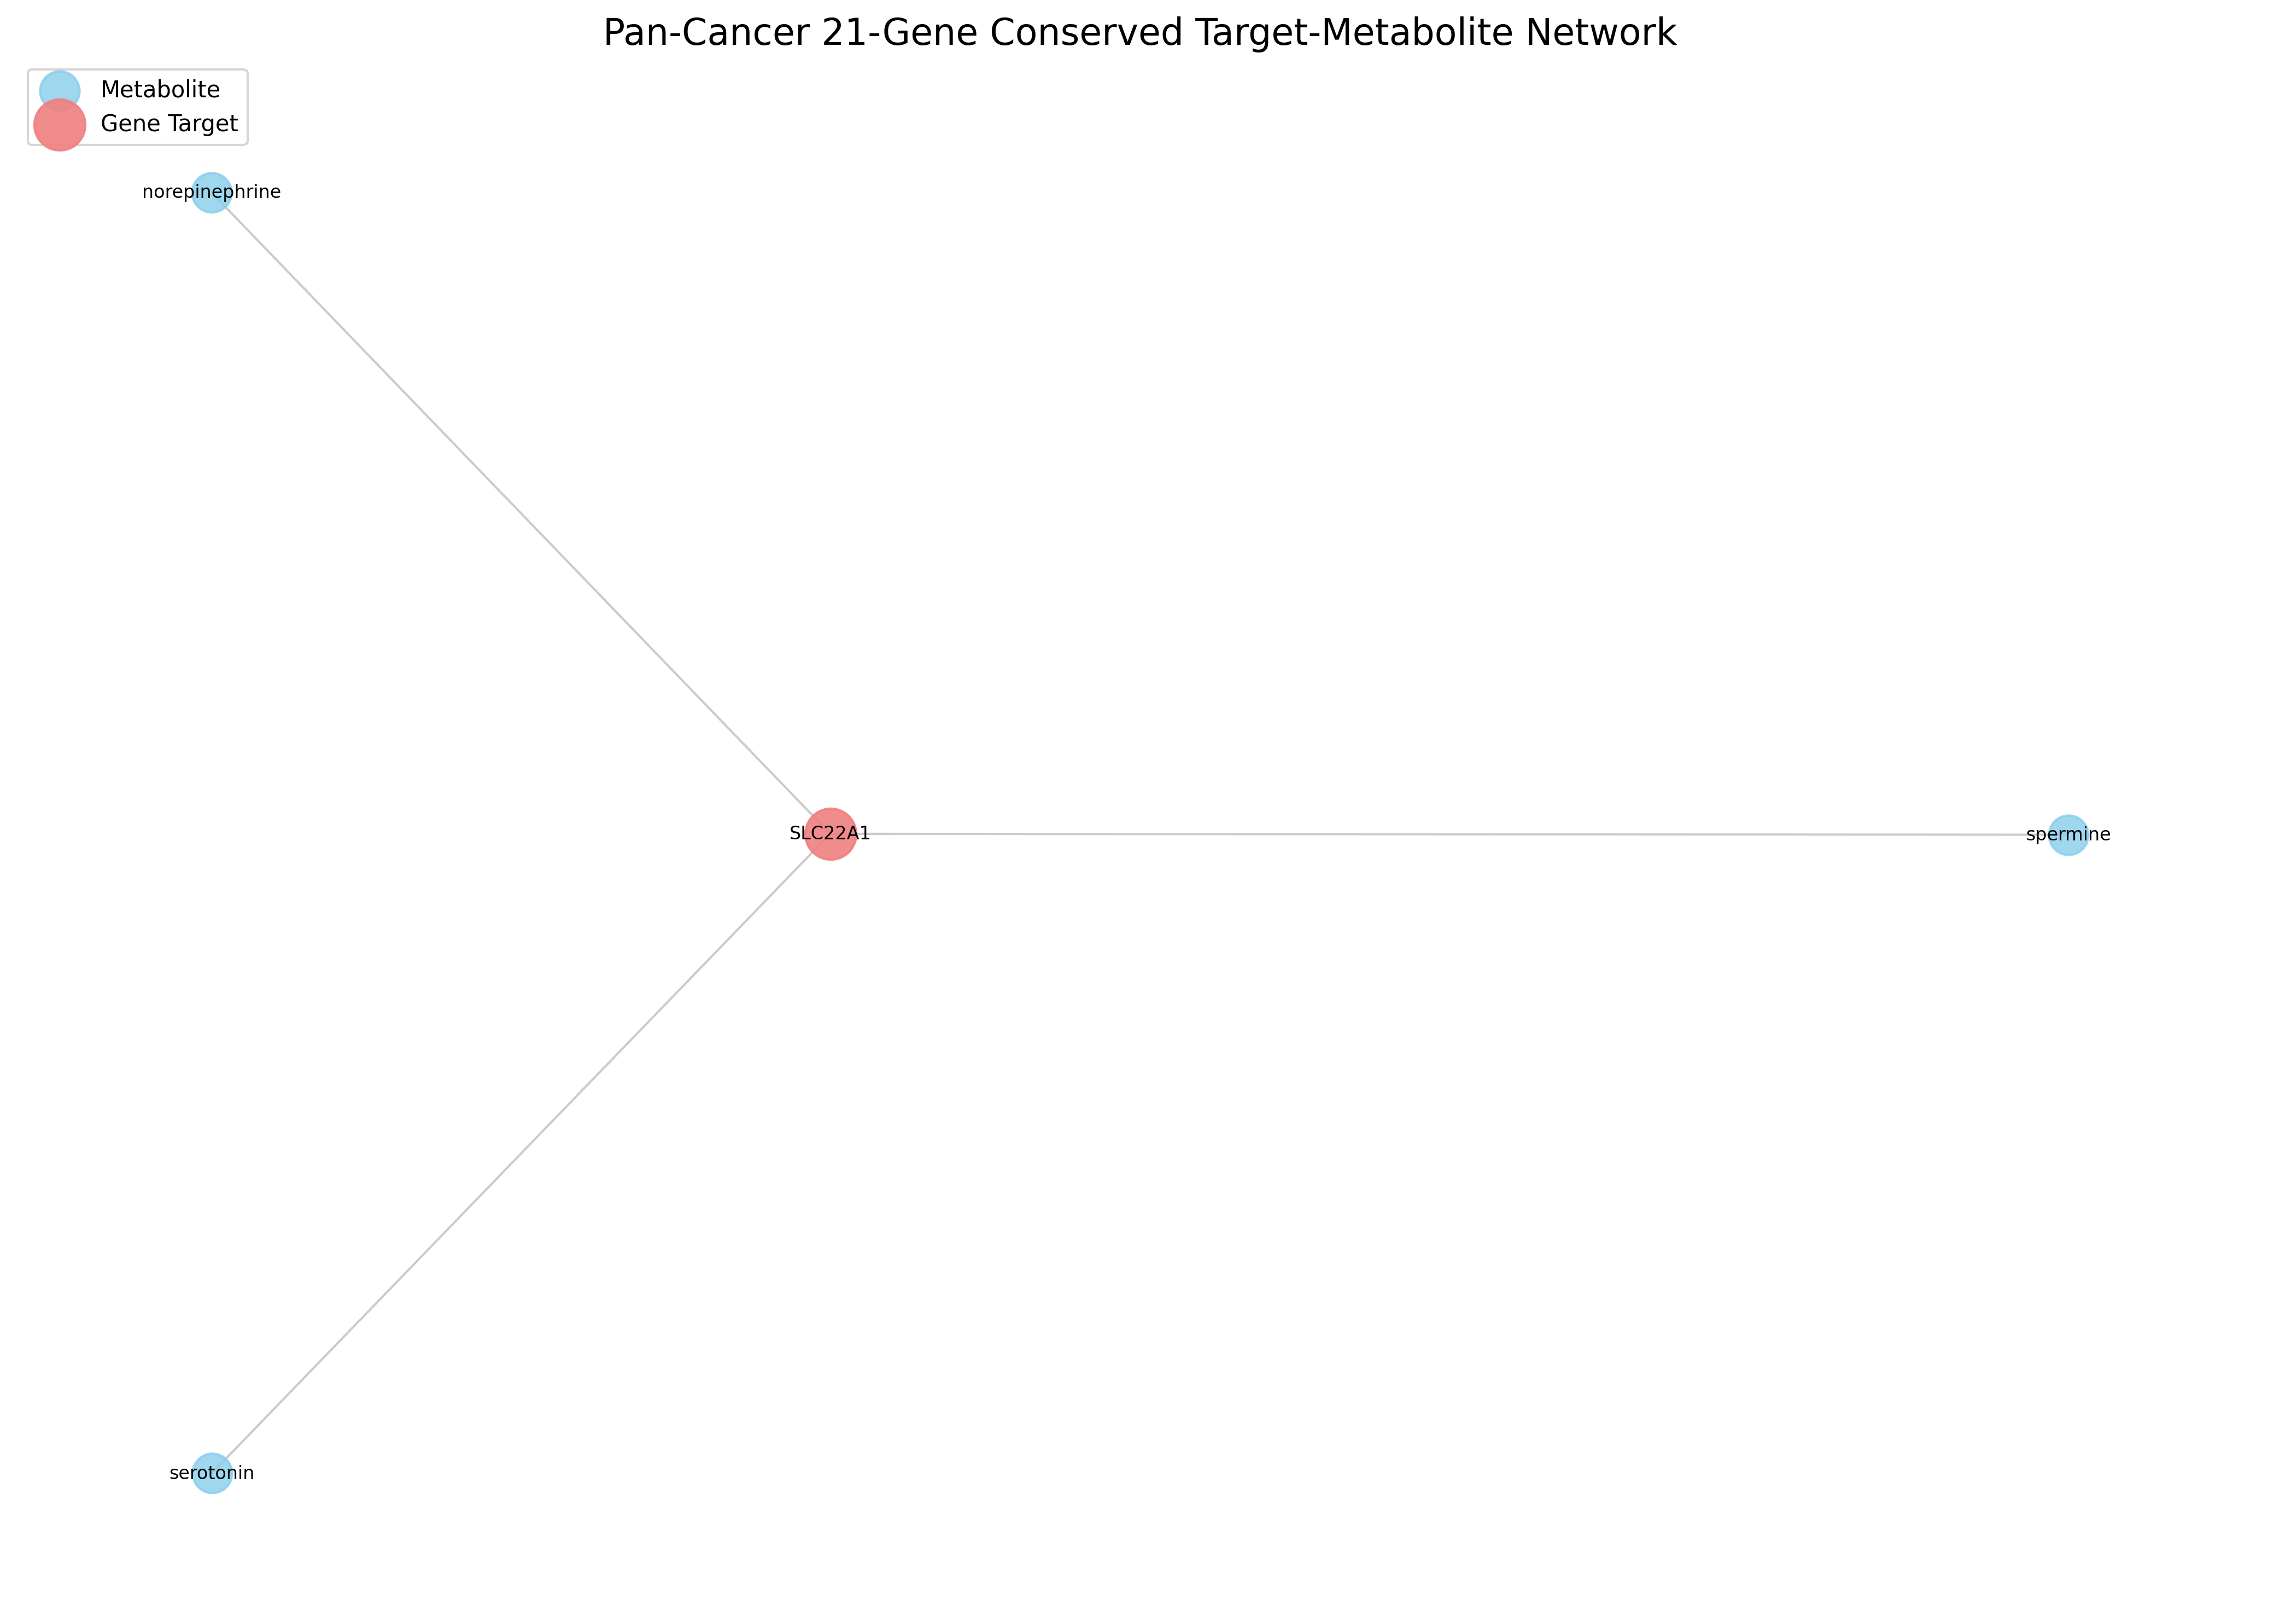

In [3]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

from IPython.display import Image, display
import os
base_dir = '..' if os.path.basename(os.getcwd()) == 'scripts' else '.'
image_path = os.path.join(base_dir, f'output/pan_cancer_meta_results/metabolite_target_network{ANALYSIS_SUFFIX}.png')
display(Image(filename=image_path))

### 3. Predictive Potential of the Conserved Gene Signature

**Goal:** Determine whether the conserved gene signature is heterogeneously expressed in primary tumors.

**Purpose:** To compute a single-cell "Metastatic Metabolic Score" across malignant cells within primary tumors. By identifying a sub-population of primary tumor cells with high expression of this signature, we hypothesize these represent pre-metastatic subclones.

**Inputs / Parameters:**
- **Gene Set:** The Conserved Pan-Cancer Genes (`output/pan_cancer_meta_results/pan_cancer_conserved_genes{ANALYSIS_SUFFIX}.csv`).
- **Algorithm:** `scanpy.tl.score_genes()` computes the average expression of the conserved genes subtracted by the average expression of a reference set of randomly sampled genes.
- **Data sources:** The 100k-cell `.h5ad` file for each cancer, explicitly filtered to `cell_type == 'malignant cell'` and subset to the primary tumor `tissue_general`.

#### 3.1 Scoring Primary Breast Cancer Cells

**Underlying Data (CSV):** `output/pan_cancer_meta_results/breast_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).


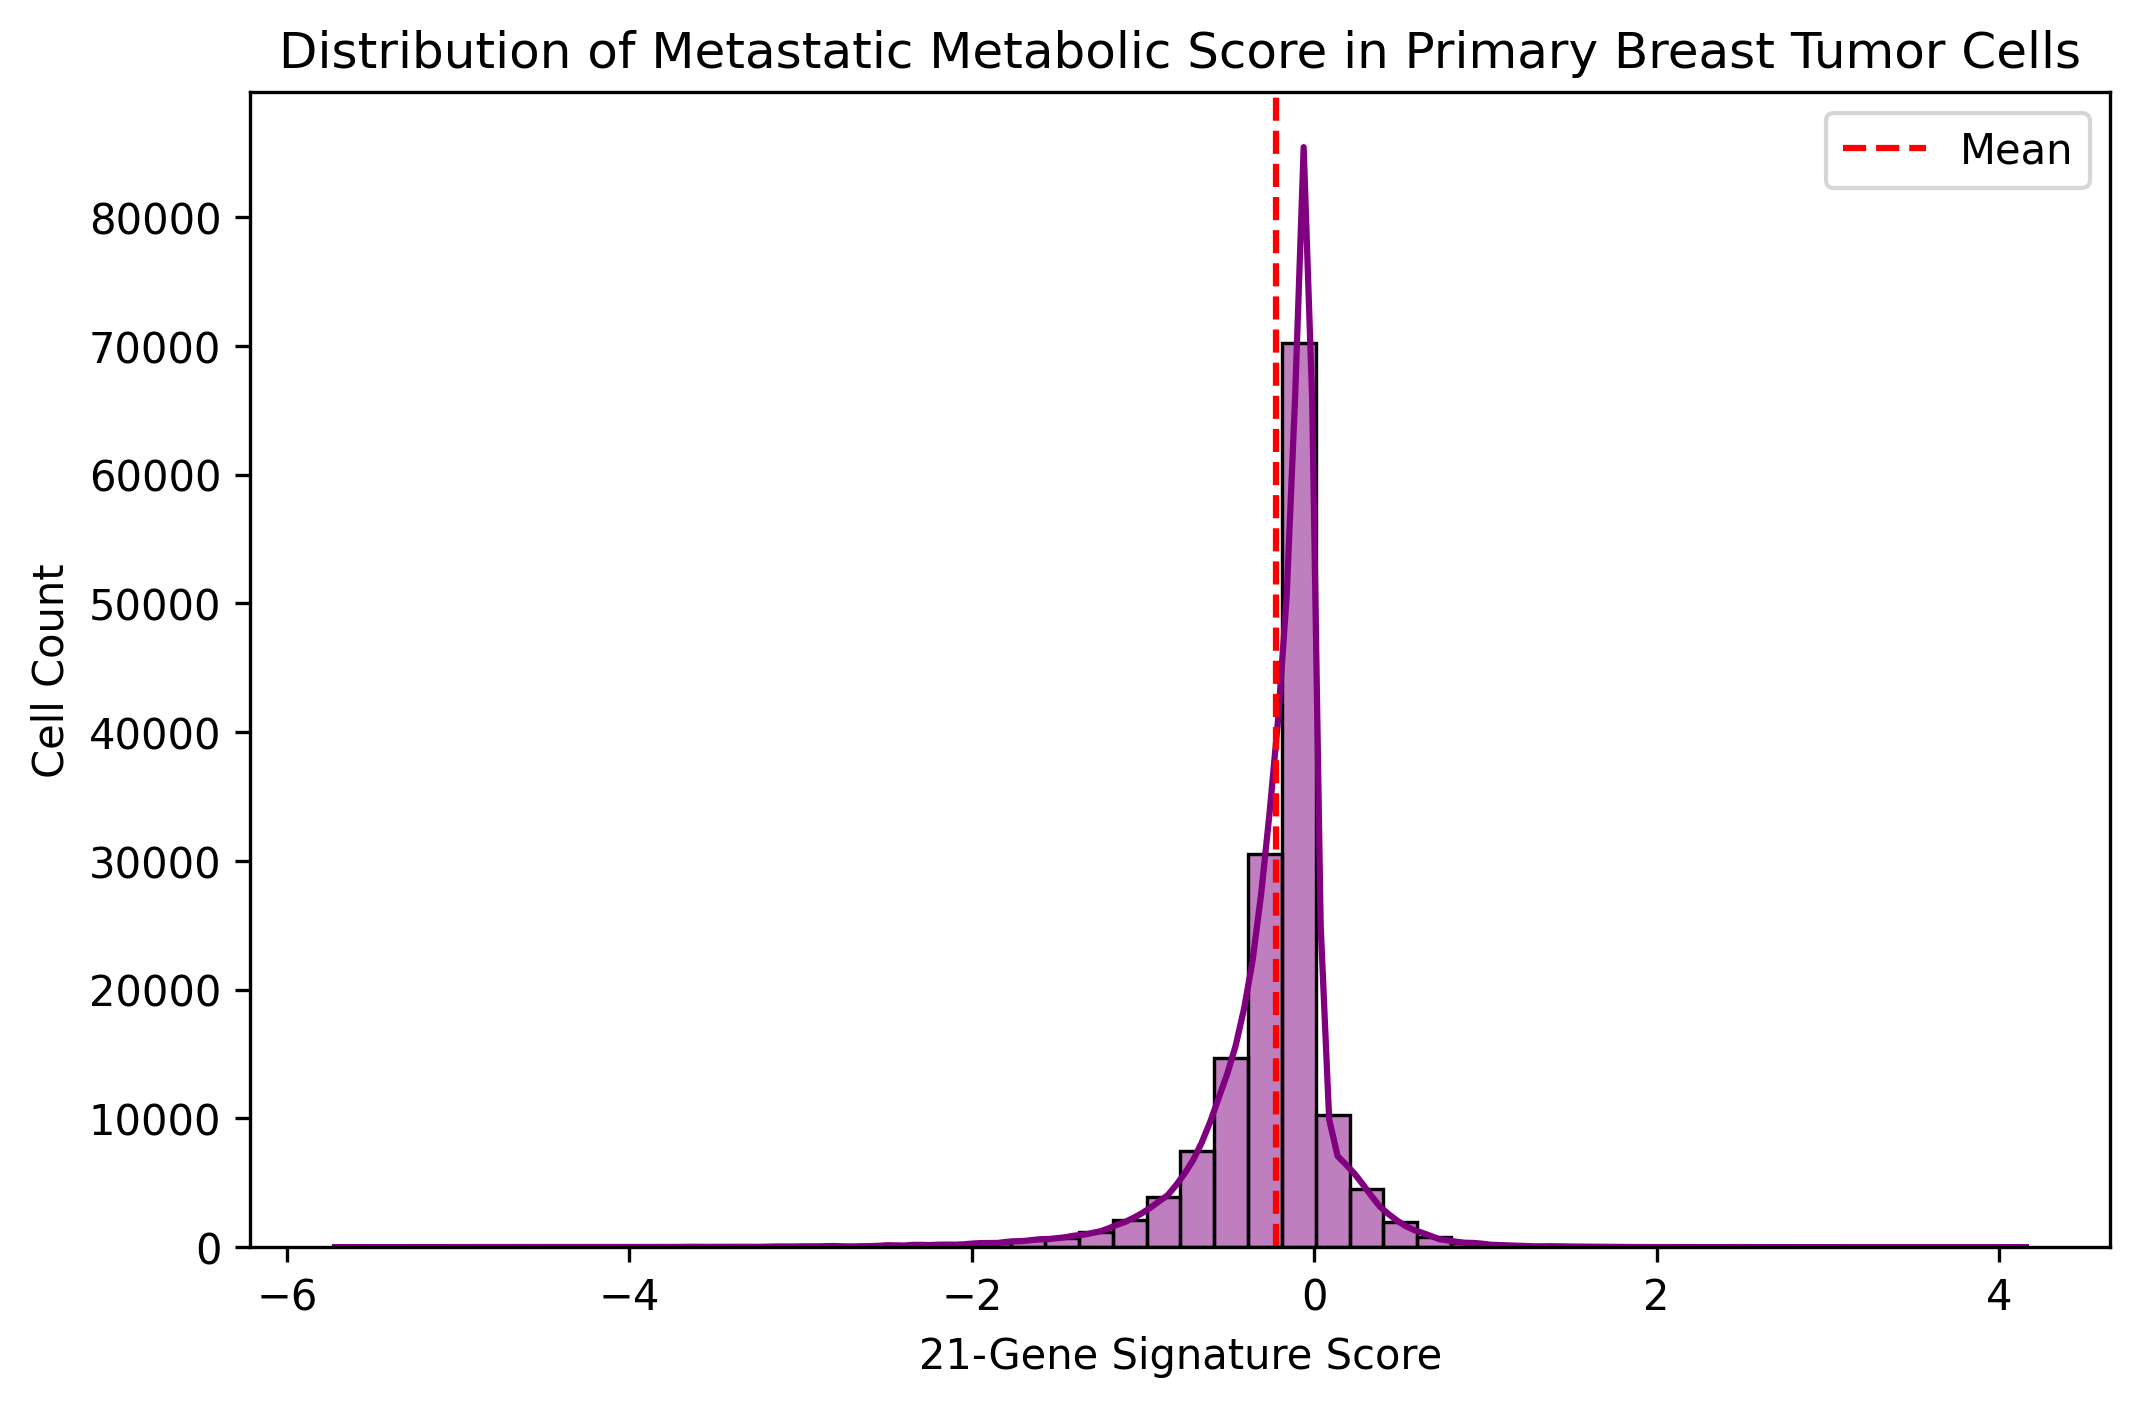

In [4]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

# 3.1 Breast Cancer
image_path = os.path.join(META_RESULTS_DIR, f'breast_primary_signature_score{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")


#### 3.2 Scoring Primary Lung Cancer Cells

**Underlying Data (CSV):** `output/pan_cancer_meta_results/lung_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).


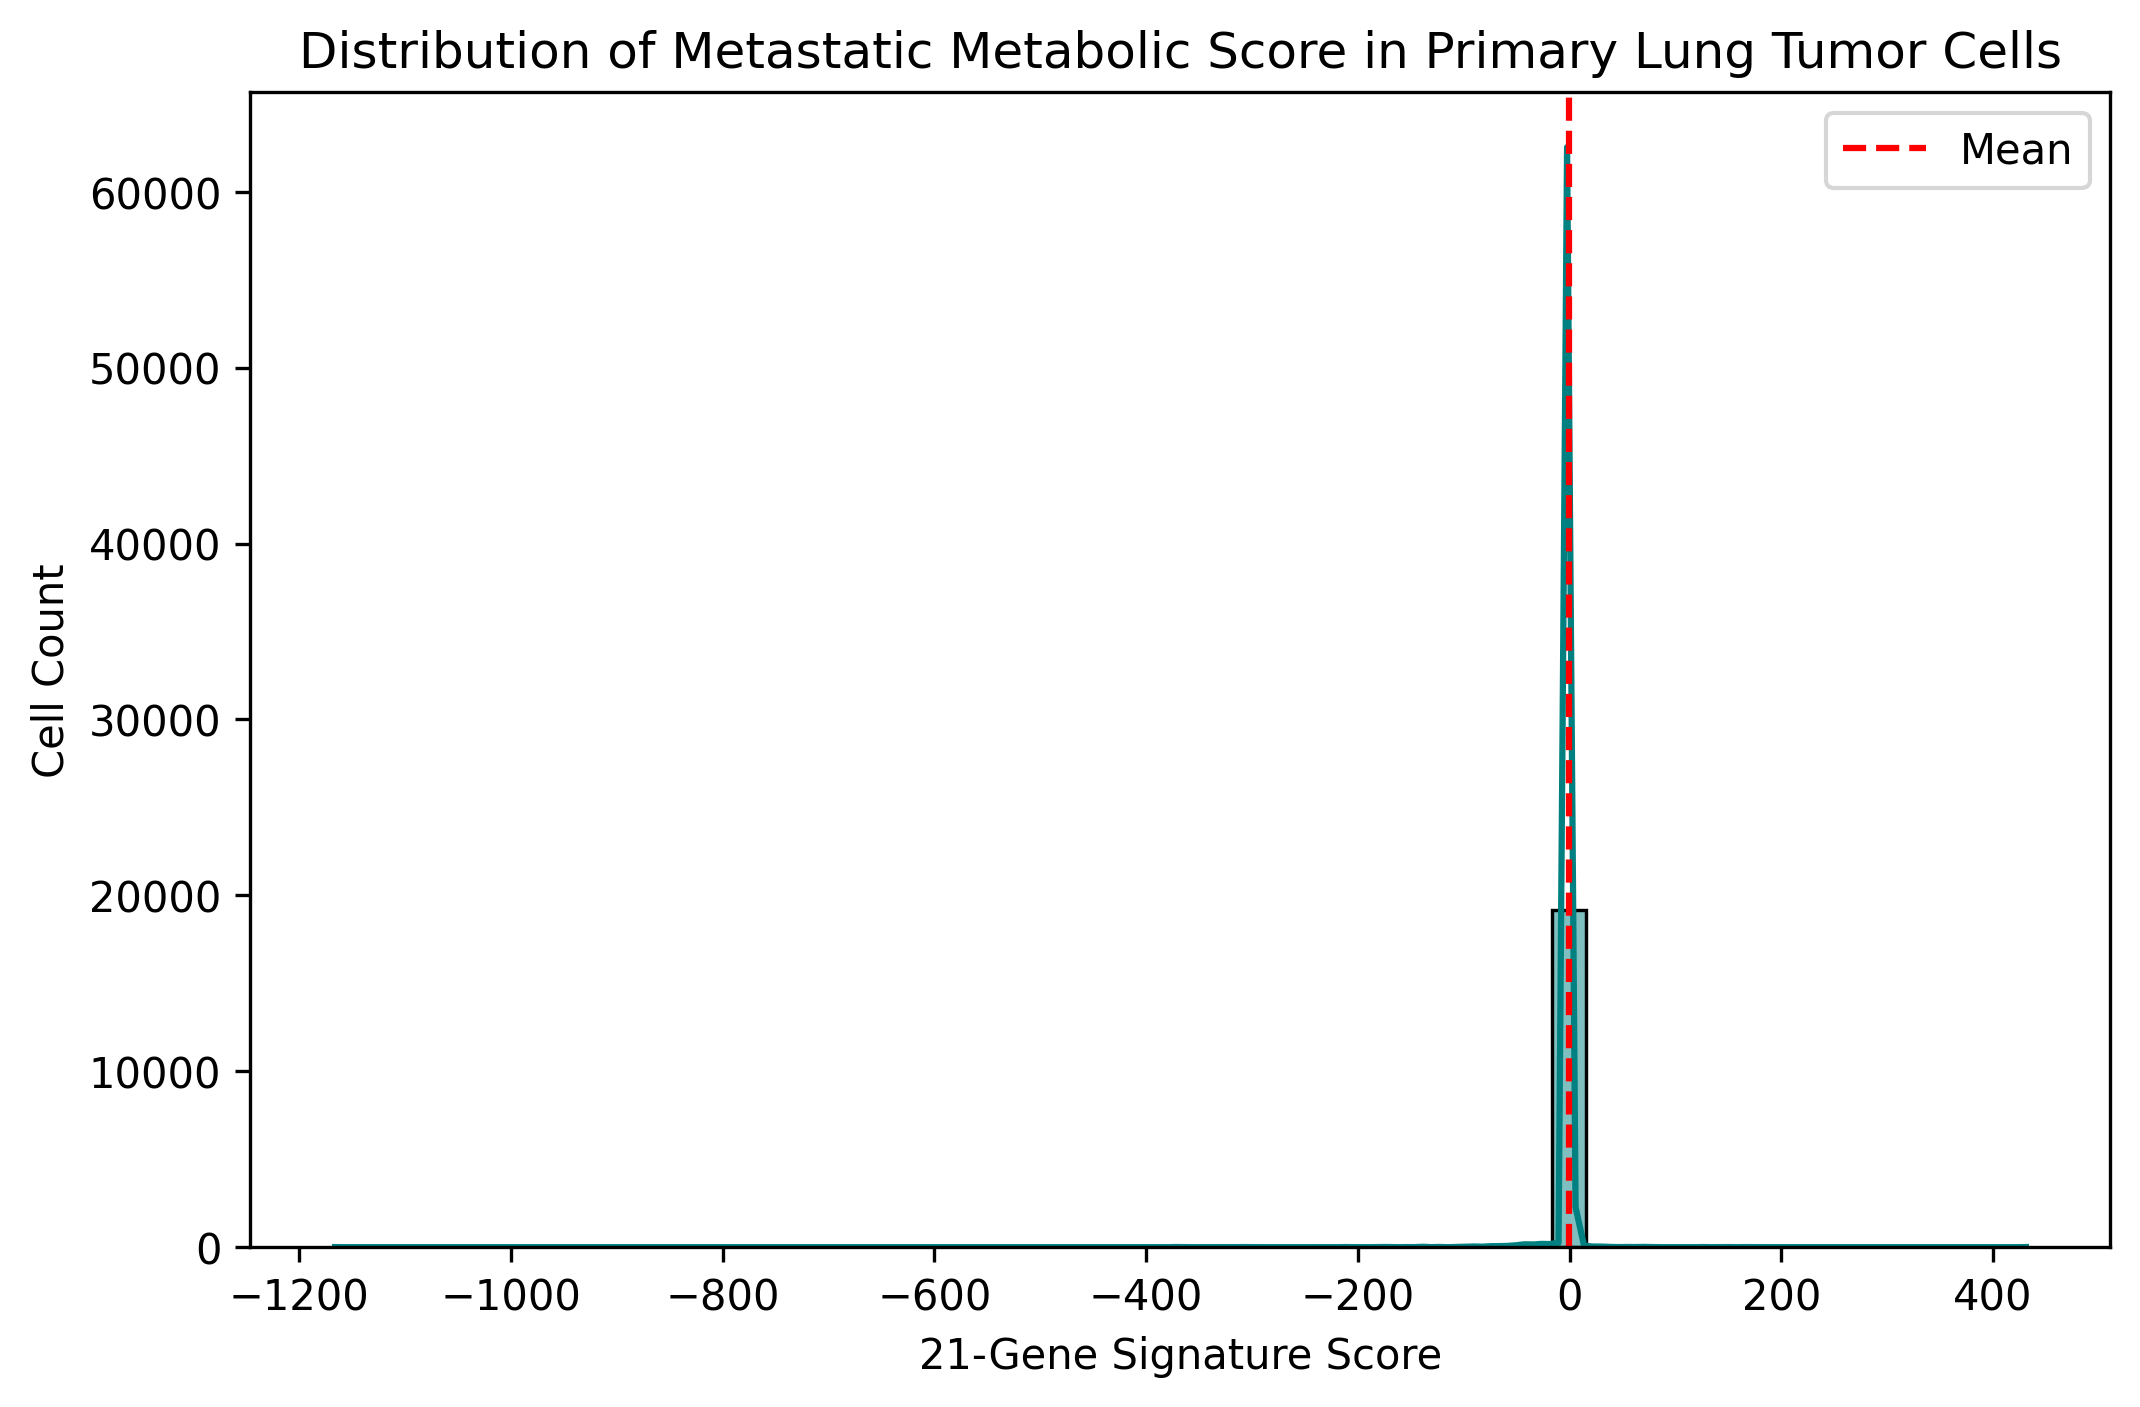

In [5]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

# 3.2 Lung Cancer
image_path = os.path.join(META_RESULTS_DIR, f'lung_primary_signature_score{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")


#### 3.3 Scoring Primary Colorectal Cancer Cells

**Underlying Data (CSV):** `output/pan_cancer_meta_results/colorectal_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).


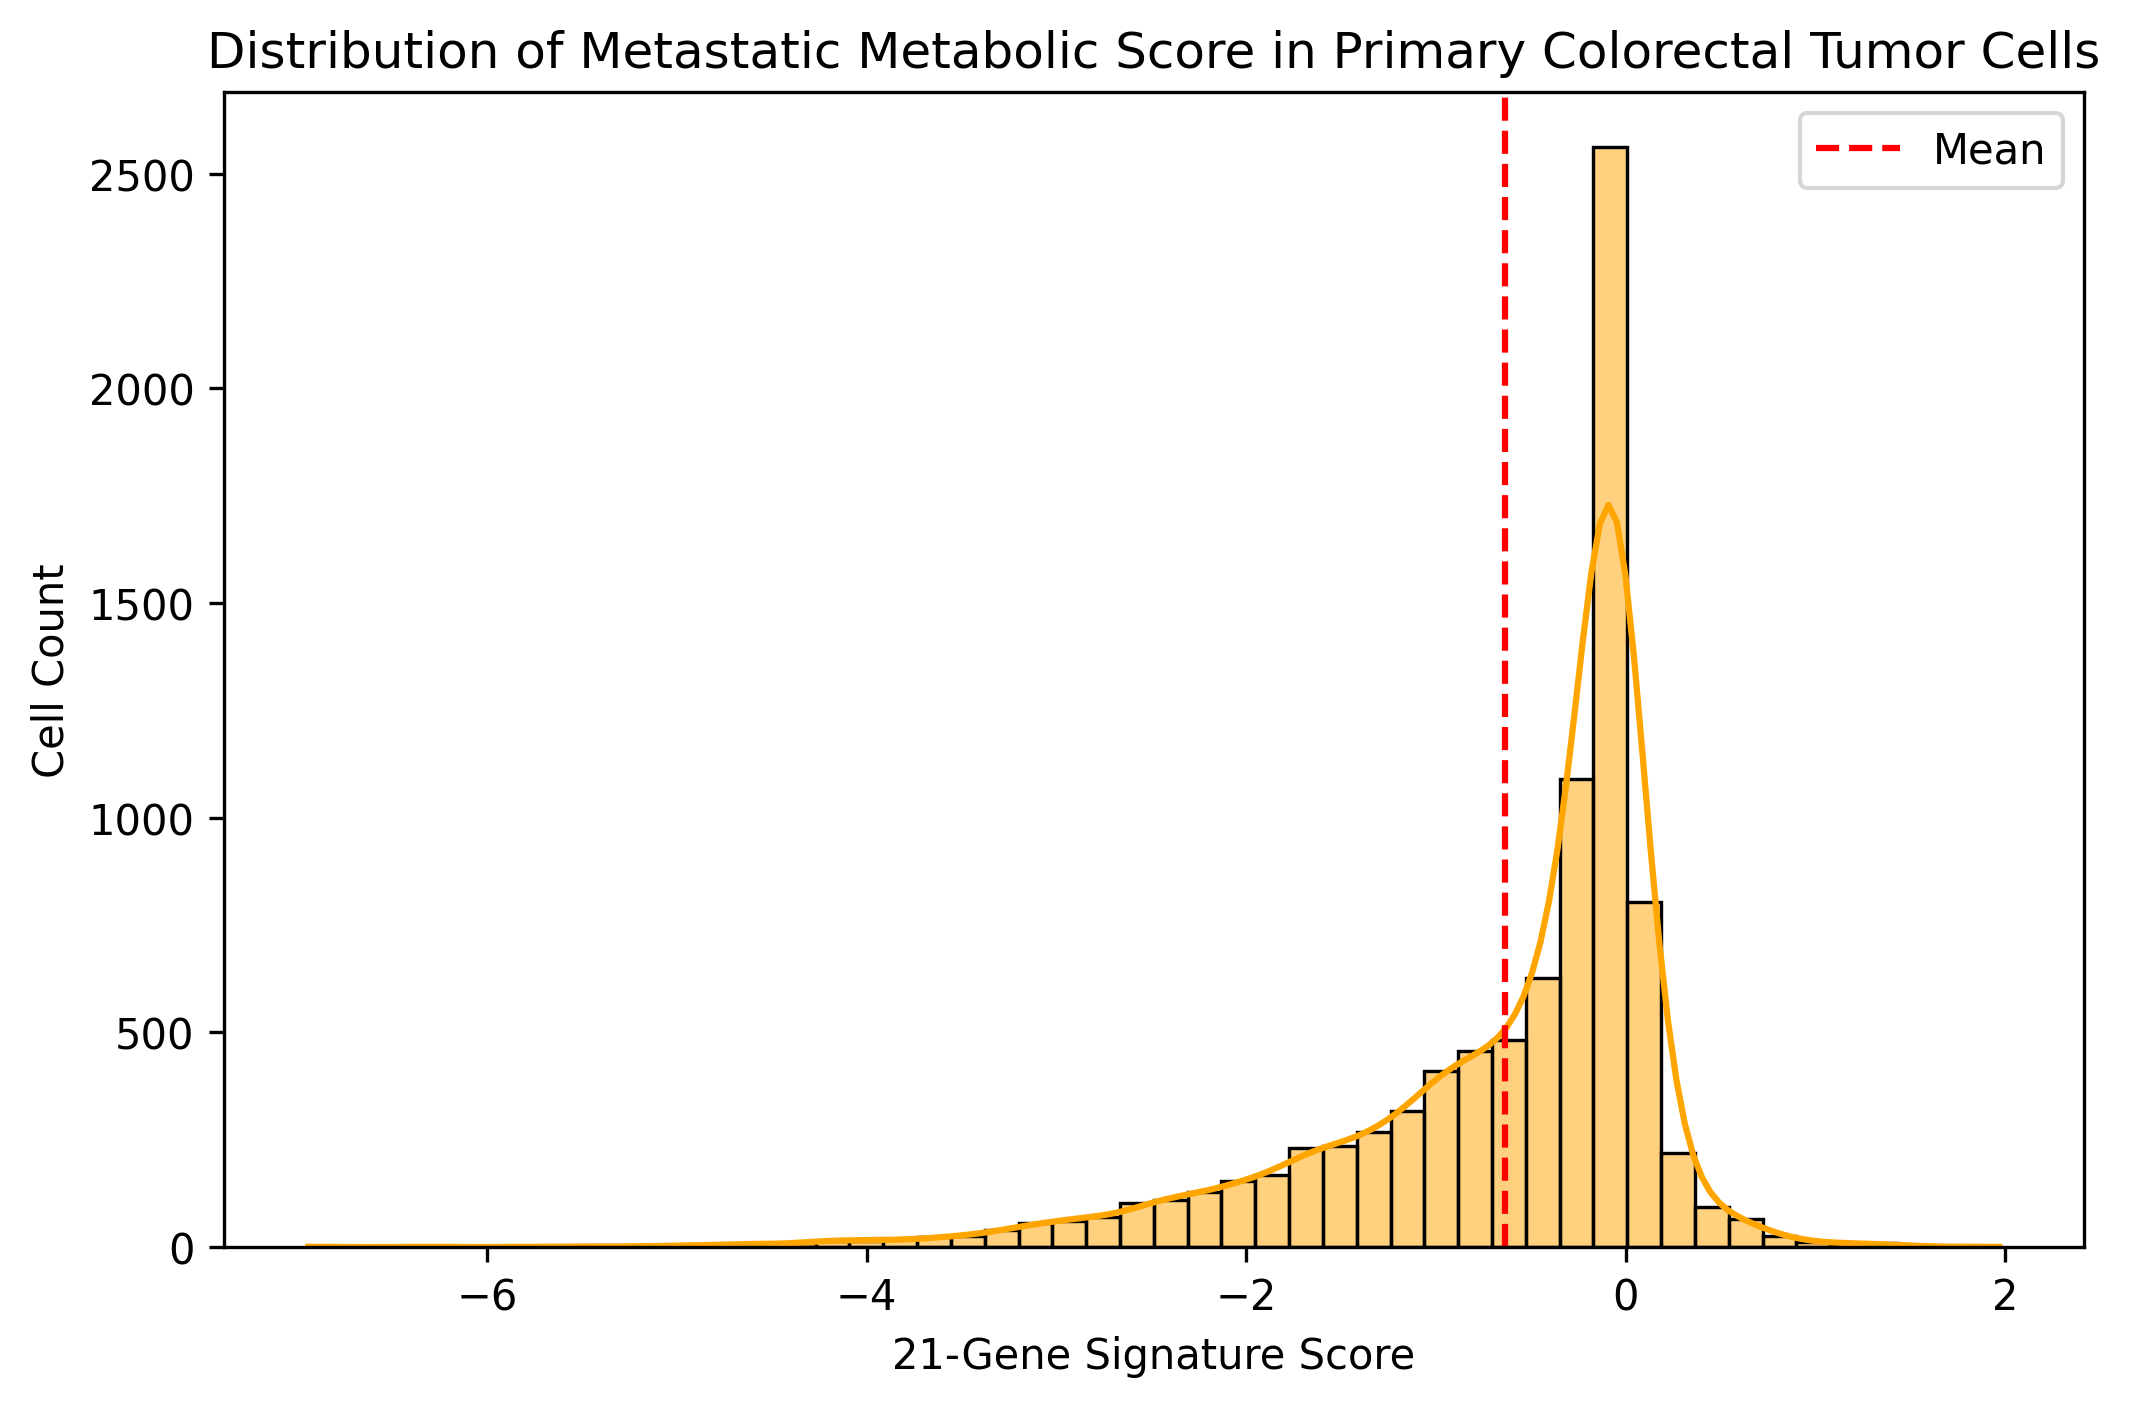

In [6]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

# 3.3 Colorectal Cancer
image_path = os.path.join(META_RESULTS_DIR, f'colorectal_primary_signature_score{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")


#### 3.4 Scoring Primary Melanoma Cancer Cells

**Underlying Data (CSV):** `output/pan_cancer_meta_results/melanoma_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).


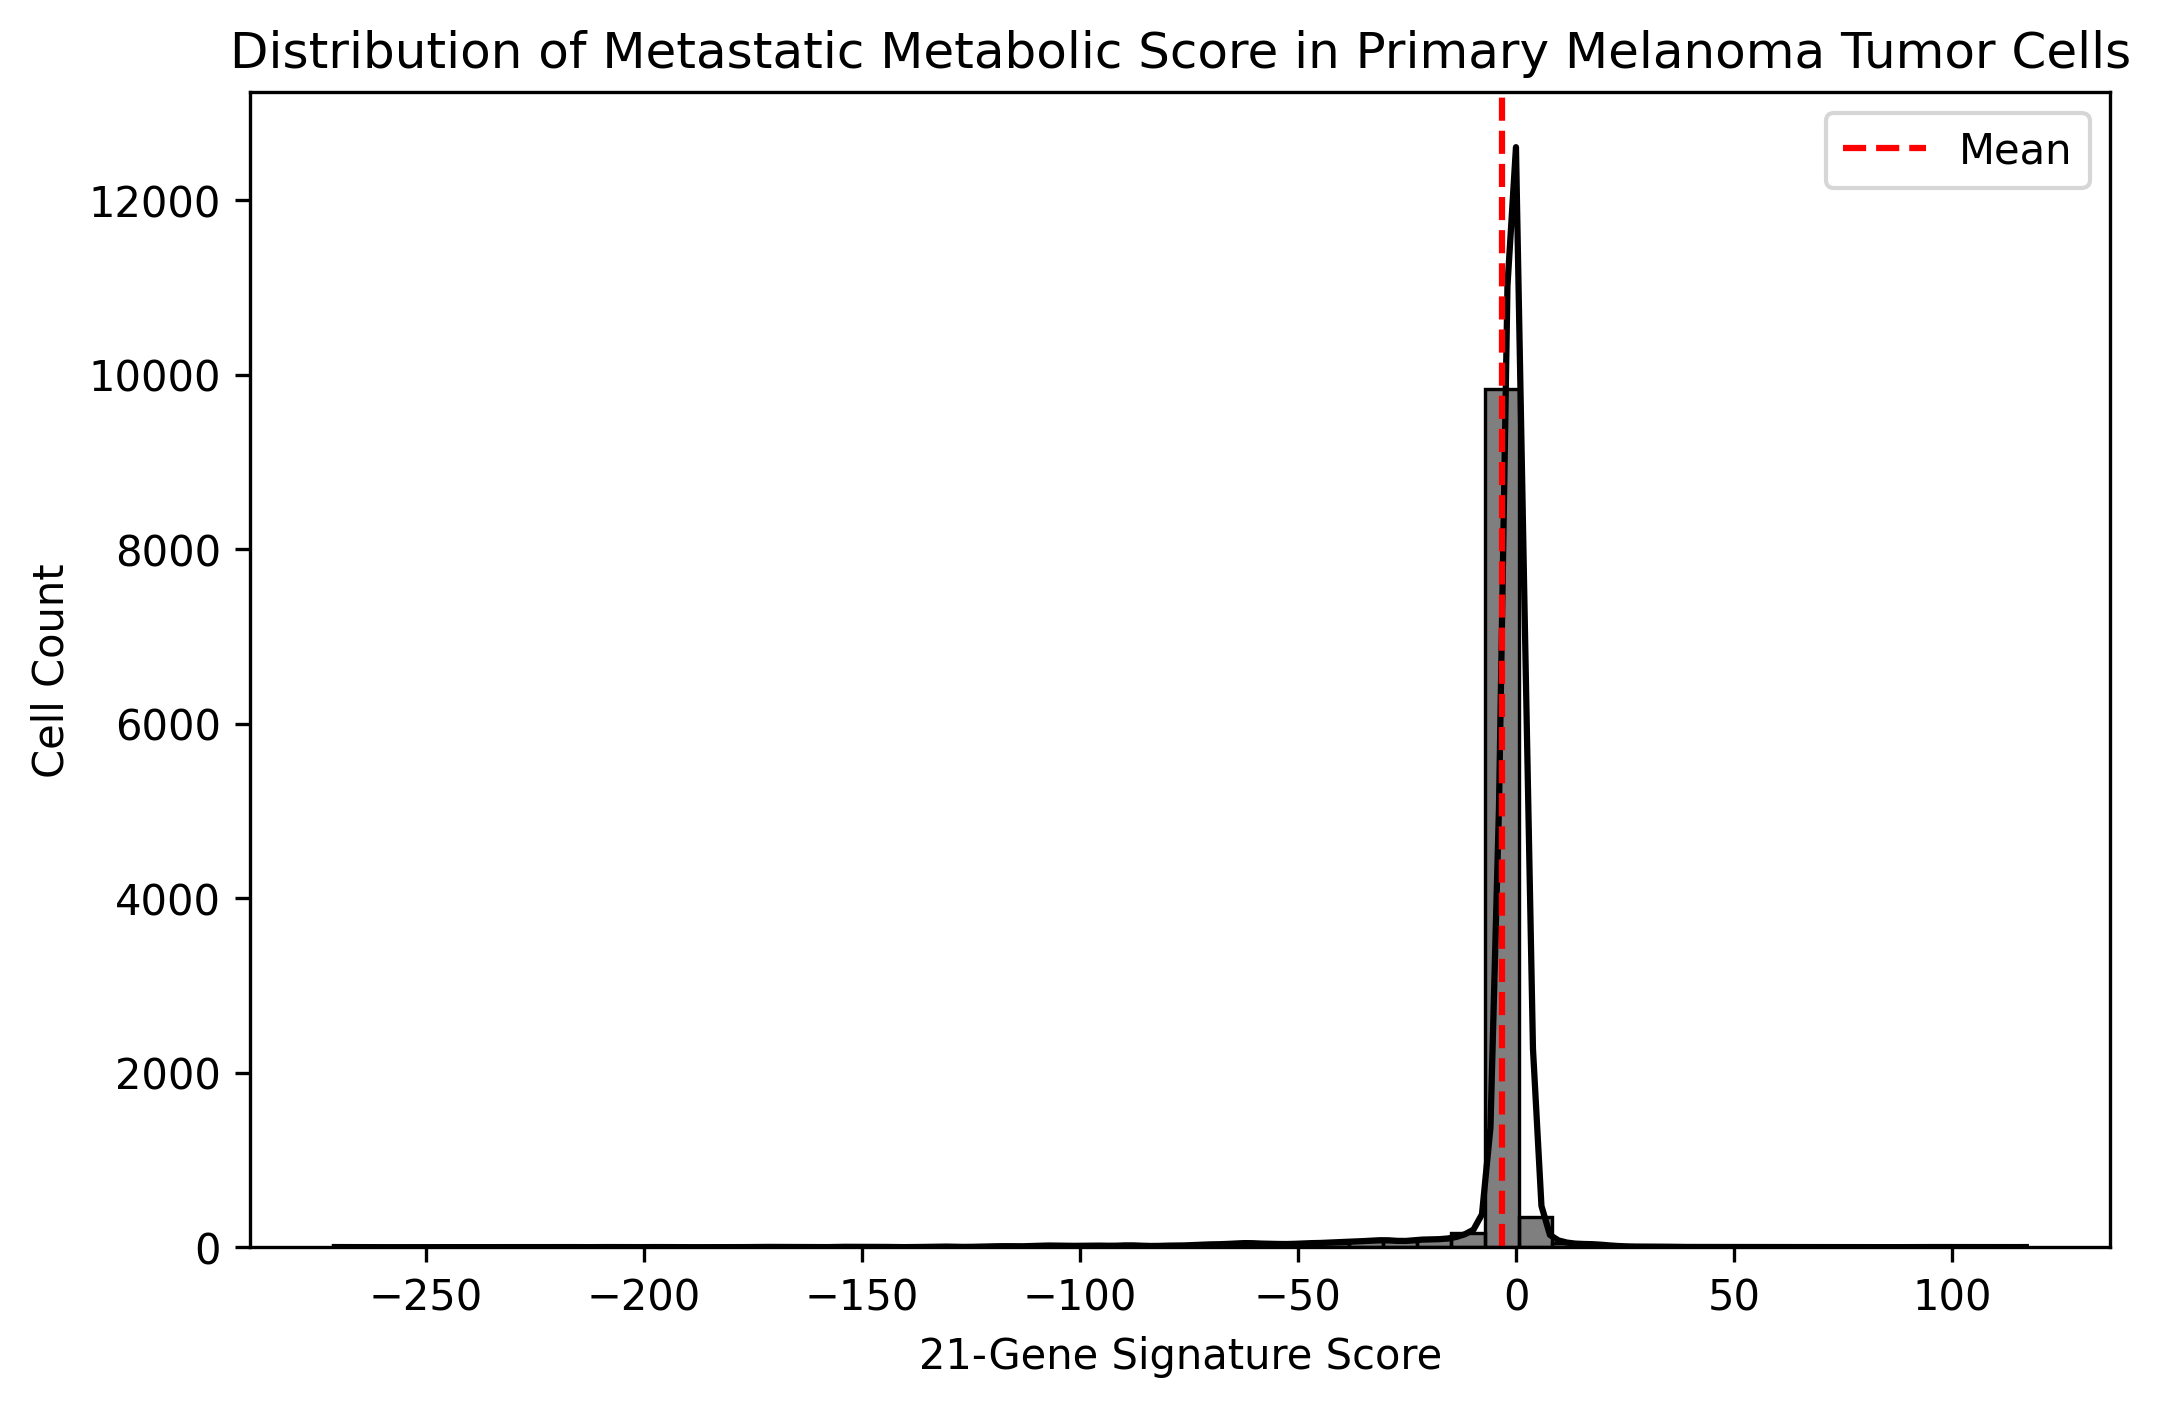

In [7]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

# 3.4 Melanoma Cancer
image_path = os.path.join(META_RESULTS_DIR, f'melanoma_primary_signature_score{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")


#### 3.5 Scoring Primary Ovarian Cancer Cells

**Underlying Data (CSV):** `output/pan_cancer_meta_results/ovarian_primary_signature_scores{ANALYSIS_SUFFIX}.csv` (contains cell_id, cell_type, tissue, and Metastatic_Signature_Score for every cell plotted below).


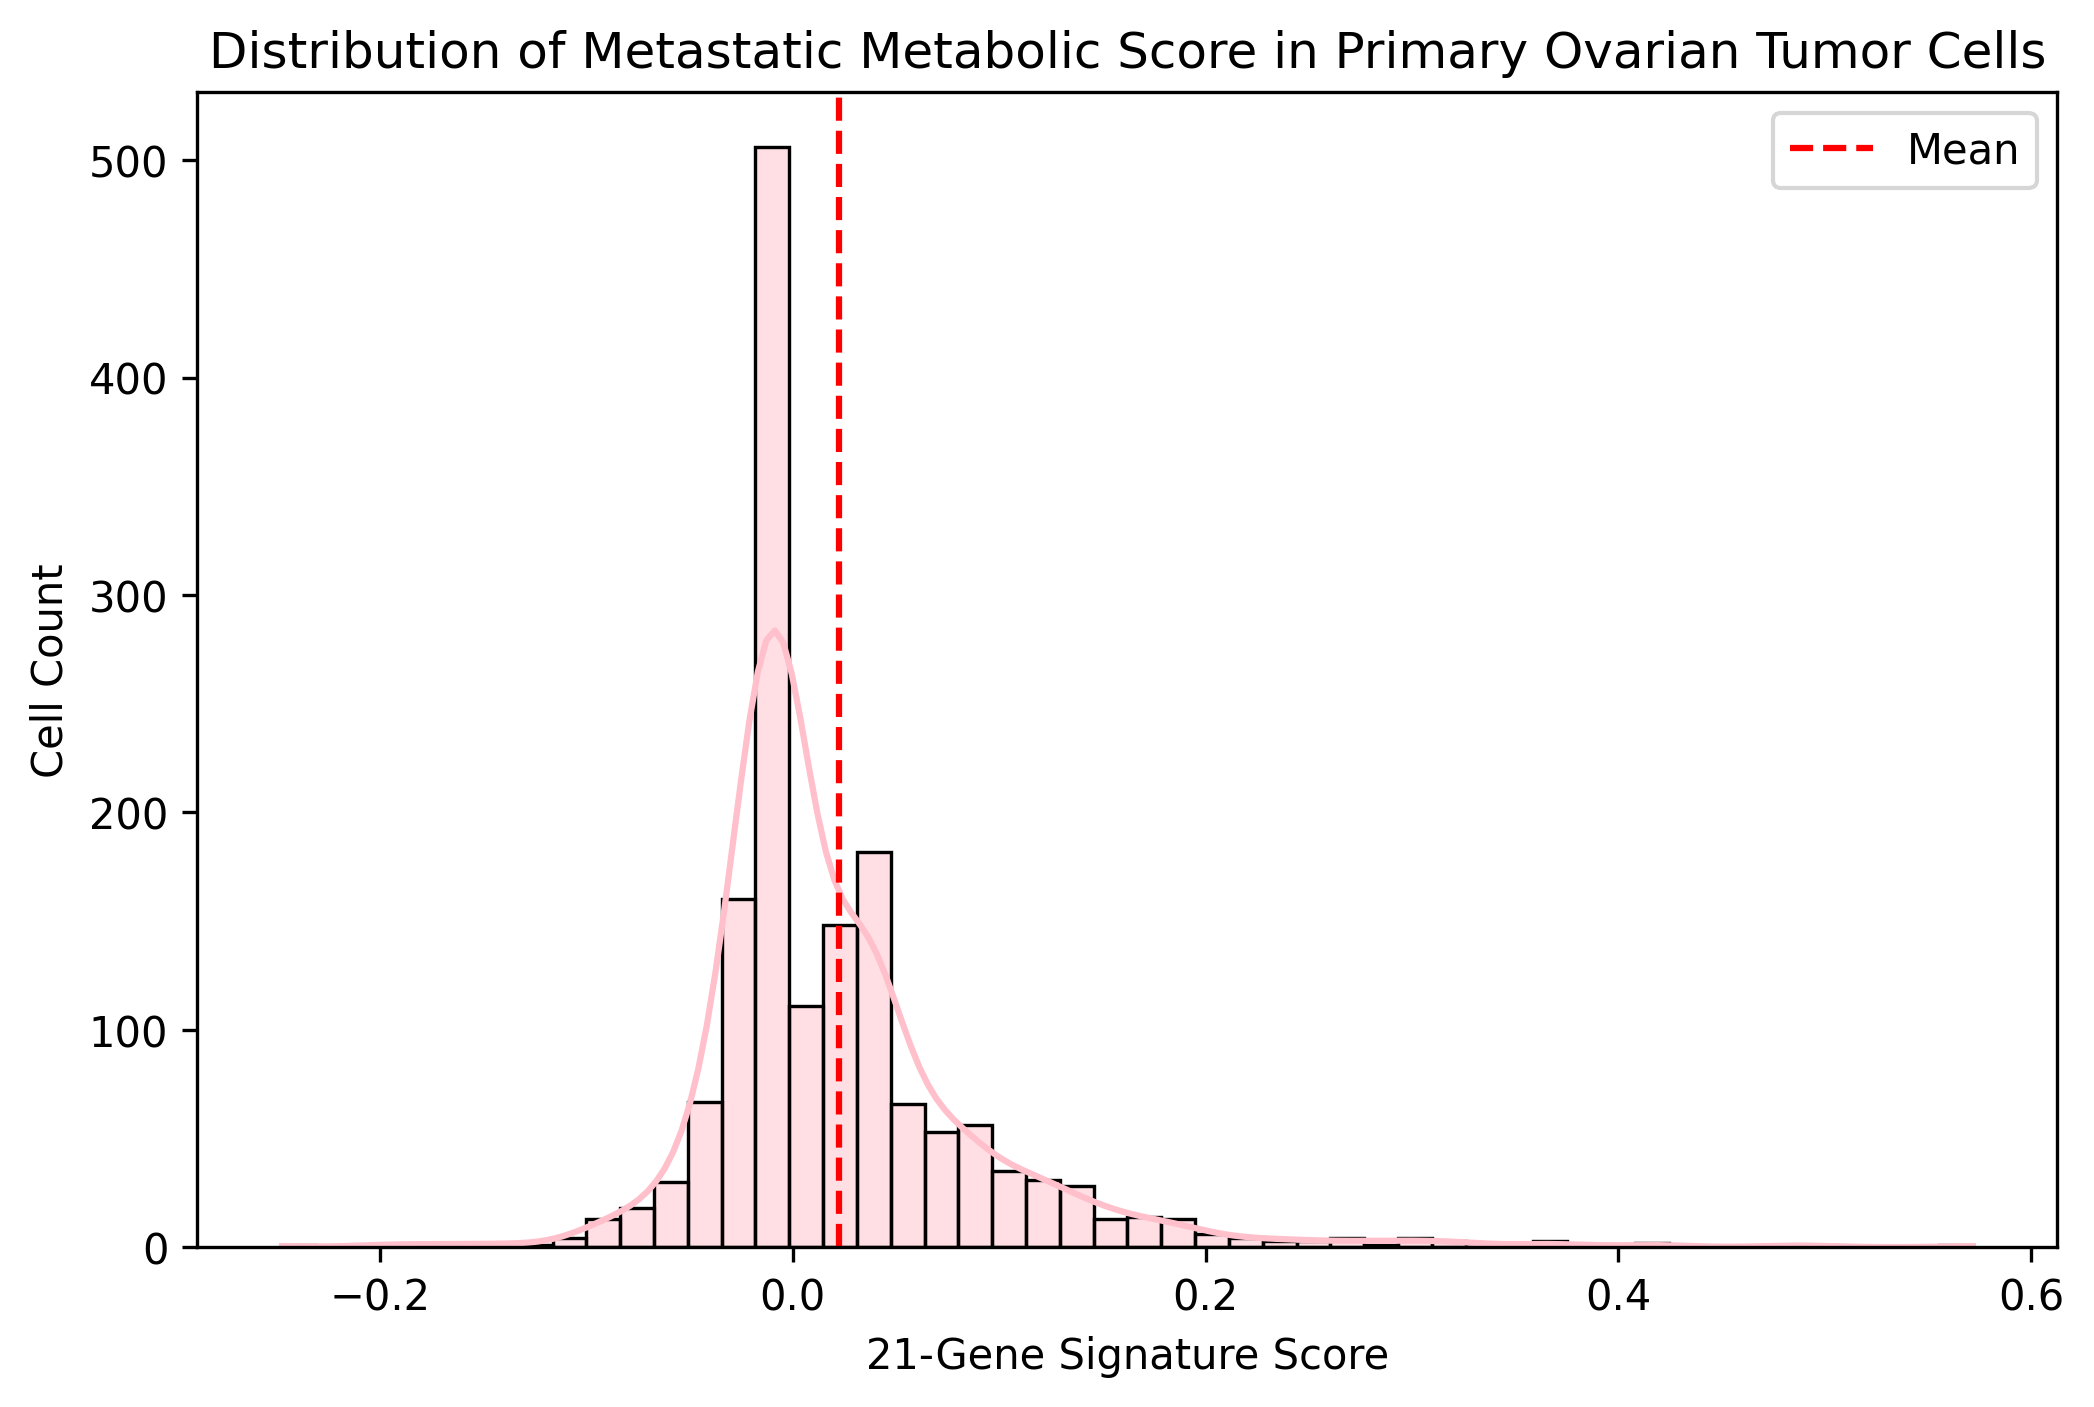

In [8]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

# 3.5 Ovarian Cancer
image_path = os.path.join(META_RESULTS_DIR, f'ovarian_primary_signature_score{ANALYSIS_SUFFIX}.png')
if os.path.exists(image_path):
    display(Image(filename=image_path))
else:
    print(f"Image not found at {image_path}")


In [10]:
import subprocess
import sys

notebook_filename = 'pan_cancer_meta_analysis.ipynb'
output_base = 'pan_cancer_meta_analysis' + ANALYSIS_SUFFIX
output_dir = os.path.join('..', 'output', 'pan_cancer_meta_results')
os.makedirs(output_dir, exist_ok=True)

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

cmd_html = [jupyter_bin, "nbconvert", "--to", "html", notebook_filename, "--output-dir", output_dir, "--output", output_base]
res_html = subprocess.run(cmd_html, capture_output=True, text=True)

if res_html.returncode == 0:
    print(f"🎉 SUCCESS: Notebook successfully exported to '{os.path.join(output_dir, output_base)}.html'")
else:
    print("❌ HTML export failed.")
    print(res_html.stderr)


🎉 SUCCESS: Notebook successfully exported to '../output/pan_cancer_meta_results/pan_cancer_meta_analysis_Br500k_Co100k_Lu500k_Me100k_Ov100k.html'
